In [24]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import minimum_filter
from matplotlib.widgets import RectangleSelector
from matplotlib.patches import Rectangle
import sys

# 导入scn_reader
from scn_reader import read_scn_file_enhanced

print("所有库导入成功！")

所有库导入成功！


In [25]:
# 定义交互式凝胶分析器类
class InteractiveGelAnalyzer:
    """交互式凝胶电泳图像分析器"""
    
    def __init__(self, image, filename):
        self.image = image
        self.filename = filename
        self.fig = None
        self.ax = None
        self.selector = None
        
    def analyze_panel(self, x1, y1, x2, y2):
        """分析选中的矩形区域"""
        # 确保坐标顺序正确
        x1, x2 = int(min(x1, x2)), int(max(x1, x2))
        y1, y2 = int(min(y1, y2)), int(max(y1, y2))
        
        # 提取panel区域
        panel = self.image[y1:y2, x1:x2]
        
        # 判断长边方向
        height, width = panel.shape
        is_vertical = height > width
        
        # 沿着长边计算平均信号强度
        if is_vertical:
            # 垂直方向（从上到下）
            profile = np.mean(panel, axis=1)  # 每行的平均值
            position = np.arange(len(profile))
            direction = "垂直方向 (上→下)"
        else:
            # 水平方向（从左到右）
            profile = np.mean(panel, axis=0)  # 每列的平均值
            position = np.arange(len(profile))
            direction = "水平方向 (左→右)"
        
        # 估算背景：使用滚动最小值
        window_size = max(10, len(profile) // 20)
        background = minimum_filter(profile, size=window_size, mode='nearest')
        
        # 去除背景
        corrected = profile - background
        corrected = np.maximum(corrected, 0)  # 确保非负
        
        return {
            'panel': panel,
            'position': position,
            'profile': profile,
            'background': background,
            'corrected': corrected,
            'direction': direction,
            'is_vertical': is_vertical,
            'coords': (x1, y1, x2, y2)
        }
    
    def plot_results(self, analysis):
        """绘制分析结果（4个子图）"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1. 原图 + 矩形框
        ax1 = axes[0, 0]
        ax1.imshow(self.image, cmap='gray')
        x1, y1, x2, y2 = analysis['coords']
        rect = Rectangle((x1, y1), x2-x1, y2-y1, 
                        fill=False, edgecolor='red', linewidth=2)
        ax1.add_patch(rect)
        ax1.set_title(f'原始图像\\n{self.filename}', fontsize=10)
        ax1.axis('off')
        
        # 2. 提取的panel
        ax2 = axes[0, 1]
        ax2.imshow(analysis['panel'], cmap='gray')
        ax2.set_title(f'选中区域\\n{analysis["direction"]}', fontsize=10)
        ax2.axis('off')
        
        # 3. 原始信号 + 背景
        ax3 = axes[1, 0]
        ax3.plot(analysis['position'], analysis['profile'], 
                label='原始信号', color='blue', linewidth=1.5)
        ax3.plot(analysis['position'], analysis['background'], 
                label='估算背景', color='red', linewidth=1.5, linestyle='--')
        ax3.set_xlabel('位置 (像素)')
        ax3.set_ylabel('信号强度')
        ax3.set_title('原始信号与背景', fontsize=10)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # 4. 去背景后的信号
        ax4 = axes[1, 1]
        ax4.plot(analysis['position'], analysis['corrected'], 
                color='green', linewidth=2)
        ax4.fill_between(analysis['position'], analysis['corrected'], 
                        alpha=0.3, color='green')
        ax4.set_xlabel('位置 (像素)')
        ax4.set_ylabel('校正后信号强度')
        max_val = analysis['corrected'].max()
        mean_val = analysis['corrected'].mean()
        ax4.set_title(f'去除背景后的信号\\n峰值: {max_val:.0f}, 平均: {mean_val:.0f}', 
                     fontsize=10)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def select_rectangle(self):
        """启动交互式矩形选择"""
        self.fig, self.ax = plt.subplots(figsize=(12, 8))
        self.ax.imshow(self.image, cmap='gray')
        self.ax.set_title(f'用鼠标框选矩形区域进行分析\\n{self.filename}\\n'
                         '提示: 拖动鼠标选择区域，释放后自动分析', 
                         fontsize=12)
        self.ax.axis('off')
        
        def onselect(eclick, erelease):
            """矩形选择回调函数"""
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            
            print(f"\\n选中区域: ({x1:.0f}, {y1:.0f}) → ({x2:.0f}, {y2:.0f})")
            print(f"区域大小: {abs(x2-x1):.0f} × {abs(y2-y1):.0f} 像素")
            
            # 分析选中区域
            analysis = self.analyze_panel(x1, y1, x2, y2)
            
            # 绘制结果
            result_fig = self.plot_results(analysis)
            plt.show()
        
        # 创建矩形选择器
        self.selector = RectangleSelector(
            self.ax, onselect,
            useblit=True,
            button=[1],  # 左键
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True,
            props=dict(facecolor='red', alpha=0.3, edgecolor='red', linewidth=2)
        )
        
        plt.show()
        return self.selector

print("InteractiveGelAnalyzer 类定义完成！")

InteractiveGelAnalyzer 类定义完成！


In [26]:
# 简单读取SCN文件并测试
import glob
import os

scn_files = sorted(glob.glob("*.scn"))
print(f"找到 {len(scn_files)} 个SCN文件")

if scn_files:
    test_file = scn_files[0]
    print(f"\n测试文件: {test_file}")
    
    # 使用read_scn_file_enhanced - 它返回3个值
    result = read_scn_file_enhanced(test_file, prefer_mode='crop')
    
    if len(result) == 3:
        img_data, dimensions, error = result
        
        if error:
            print(f"读取失败: {error}")
        elif img_data is not None:
            print(f"✓ 读取成功！")
            print(f"图像尺寸: {img_data.shape}")
            print(f"像素值范围: [{img_data.min()}, {img_data.max()}]")
            print(f"数据类型: {img_data.dtype}")
        else:
            print("读取失败：返回None")
    else:
        print(f"意外的返回值数量: {len(result)}")
else:
    print("未找到SCN文件！")

找到 1 个SCN文件

测试文件: 2022-12-12_Q6_Q6_Q5_M2_L2AG2_L2BG2_L3AG2_L3BG2.scn
✓ 读取成功！
图像尺寸: (396, 683)
像素值范围: [0, 65535]
数据类型: uint16


## 启动交互式分析

运行下面的代码后：
1. 会显示凝胶图像
2. 用鼠标拖动选择一个矩形区域
3. 释放鼠标后自动显示分析结果（4个子图）

**使用说明：**
- 选择一个纵向或横向的lane区域
- 系统会自动检测长边方向
- 沿着长边计算平均信号强度
- 使用滚动最小值估算背景并去除

启动交互式分析器...
图像: 2022-12-12_Q6_Q6_Q5_M2_L2AG2_L2BG2_L3AG2_L3BG2.scn
尺寸: (396, 683)

请在图像上用鼠标拖动框选一个矩形区域


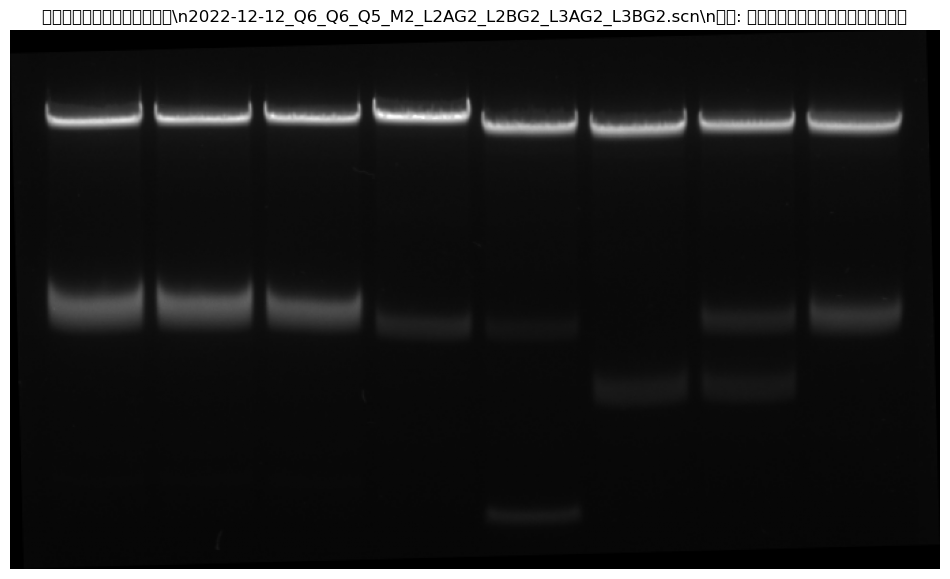

In [27]:
# 创建分析器并启动交互式选择
if 'img_data' in globals() and img_data is not None:
    print("启动交互式分析器...")
    print(f"图像: {test_file}")
    print(f"尺寸: {img_data.shape}")
    print("\n请在图像上用鼠标拖动框选一个矩形区域")
    
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    analyzer.select_rectangle()
else:
    print("请先运行上面的单元格加载图像数据！")

## 示例：直接分析一个区域

如果交互式选择不方便（例如在远程环境），也可以直接指定坐标进行分析：

分析区域: (40, 50) → (80, 150)
区域大小: 40 × 100 像素

方向: 垂直方向 (上→下)
数据点数: 100
原始信号范围: [3097.7, 54724.4]
校正后信号峰值: 35867.7
校正后信号平均值: 3186.0



/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21306 (\N{CJK UN

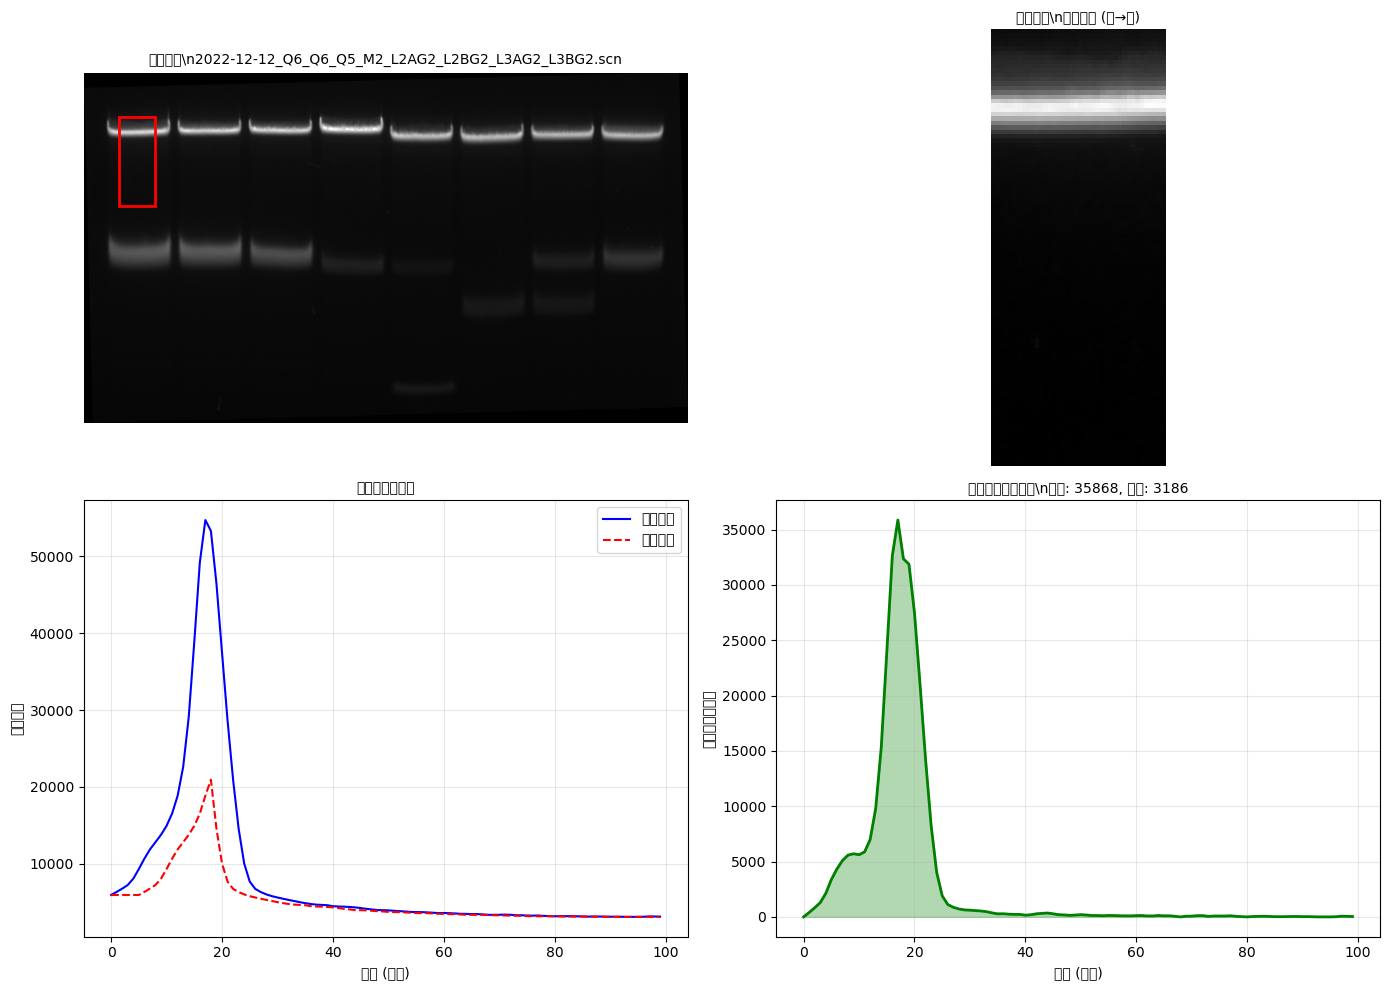

In [28]:
# 示例：分析第一个lane（垂直方向）
if 'img_data' in globals() and img_data is not None:
    # 创建分析器
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    
    # 选择第一个lane的区域 (x1, y1, x2, y2)
    # 这是一个垂直的lane
    x1, y1 = 40, 50
    x2, y2 = 80, 150
    
    print(f"分析区域: ({x1}, {y1}) → ({x2}, {y2})")
    print(f"区域大小: {x2-x1} × {y2-y1} 像素\n")
    
    # 分析选中区域
    analysis = analyzer.analyze_panel(x1, y1, x2, y2)
    
    print(f"方向: {analysis['direction']}")
    print(f"数据点数: {len(analysis['position'])}")
    print(f"原始信号范围: [{analysis['profile'].min():.1f}, {analysis['profile'].max():.1f}]")
    print(f"校正后信号峰值: {analysis['corrected'].max():.1f}")
    print(f"校正后信号平均值: {analysis['corrected'].mean():.1f}\n")
    
    # 绘制结果
    fig = analyzer.plot_results(analysis)
    plt.show()
else:
    print("请先运行上面的单元格加载图像数据！")

## 示例2：分析水平方向的band

现在让我们分析一个水平方向的band：

分析区域: (30, 80) → (650, 120)
区域大小: 620 × 40 像素

方向: 水平方向 (左→右)
数据点数: 620
原始信号范围: [3418.5, 4871.4]
校正后信号峰值: 1100.9
校正后信号平均值: 255.5



/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21306 (\N{CJK UN

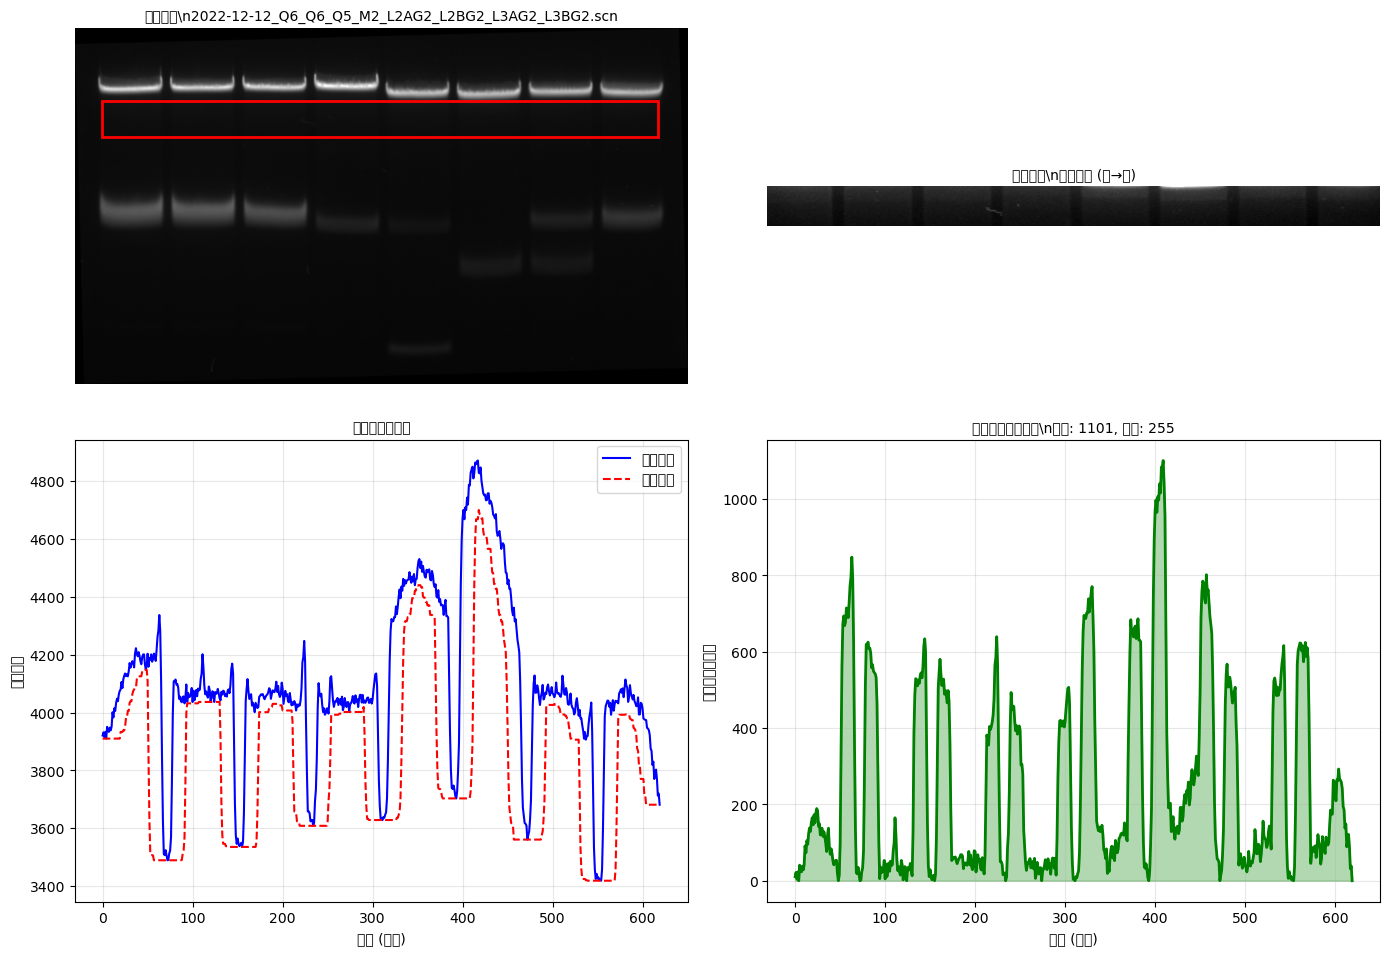

In [29]:
# 示例：分析一个水平的band（横向）
if 'img_data' in globals() and img_data is not None:
    # 创建分析器
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    
    # 选择一个水平band的区域 (x1, y1, x2, y2)
    # 这是一个横向的band
    x1, y1 = 30, 80
    x2, y2 = 650, 120
    
    print(f"分析区域: ({x1}, {y1}) → ({x2}, {y2})")
    print(f"区域大小: {x2-x1} × {y2-y1} 像素\n")
    
    # 分析选中区域
    analysis = analyzer.analyze_panel(x1, y1, x2, y2)
    
    print(f"方向: {analysis['direction']}")
    print(f"数据点数: {len(analysis['position'])}")
    print(f"原始信号范围: [{analysis['profile'].min():.1f}, {analysis['profile'].max():.1f}]")
    print(f"校正后信号峰值: {analysis['corrected'].max():.1f}")
    print(f"校正后信号平均值: {analysis['corrected'].mean():.1f}\n")
    
    # 绘制结果
    fig = analyzer.plot_results(analysis)
    plt.show()
else:
    print("请先运行上面的单元格加载图像数据！")

## 示例3：批量分析多个lanes

批量分析图像中的多个垂直lanes：

In [30]:
# 批量分析多个垂直lanes
if 'img_data' in globals() and img_data is not None:
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    
    # 定义8个lane的位置（上排）
    lane_positions = [
        (40, 50, 80, 150),    # Lane 1
        (100, 50, 140, 150),  # Lane 2
        (160, 50, 200, 150),  # Lane 3
        (220, 50, 260, 150),  # Lane 4
        (280, 50, 320, 150),  # Lane 5
        (360, 50, 400, 150),  # Lane 6
        (440, 50, 480, 150),  # Lane 7
        (540, 50, 580, 150),  # Lane 8
    ]
    
    results_list = []
    
    print(f"批量分析 {len(lane_positions)} 个lanes:\n")
    print("=" * 80)
    
    for i, (x1, y1, x2, y2) in enumerate(lane_positions, 1):
        analysis = analyzer.analyze_panel(x1, y1, x2, y2)
        
        peak_intensity = analysis['corrected'].max()
        mean_intensity = analysis['corrected'].mean()
        total_signal = analysis['corrected'].sum()
        
        results_list.append({
            'lane': i,
            'peak': peak_intensity,
            'mean': mean_intensity,
            'total': total_signal
        })
        
        print(f"Lane {i}: 峰值={peak_intensity:6.1f}, 平均={mean_intensity:6.1f}, 总和={total_signal:8.1f}")
    
    print("=" * 80)
    
    # 找出信号最强的lane
    max_lane = max(results_list, key=lambda x: x['peak'])
    print(f"\n信号最强的lane: Lane {max_lane['lane']} (峰值: {max_lane['peak']:.1f})")
else:
    print("请先运行上面的单元格加载图像数据！")

批量分析 8 个lanes:

Lane 1: 峰值=35867.7, 平均=3186.0, 总和=318597.9
Lane 2: 峰值=26323.8, 平均=2616.5, 总和=261653.7
Lane 3: 峰值=23304.8, 平均=2393.0, 总和=239301.4
Lane 4: 峰值=29979.1, 平均=2932.3, 总和=293230.4
Lane 5: 峰值=39056.7, 平均=3640.4, 总和=364038.8
Lane 6: 峰值=29757.2, 平均=3106.8, 总和=310681.3
Lane 7: 峰值=28523.7, 平均=3093.9, 总和=309386.9
Lane 8: 峰值=22809.2, 平均=2678.4, 总和=267843.4

信号最强的lane: Lane 5 (峰值: 39056.7)


/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2619198538.py:39: UserWarning: Glyph 21508 (\N{CJK UNIFIED I

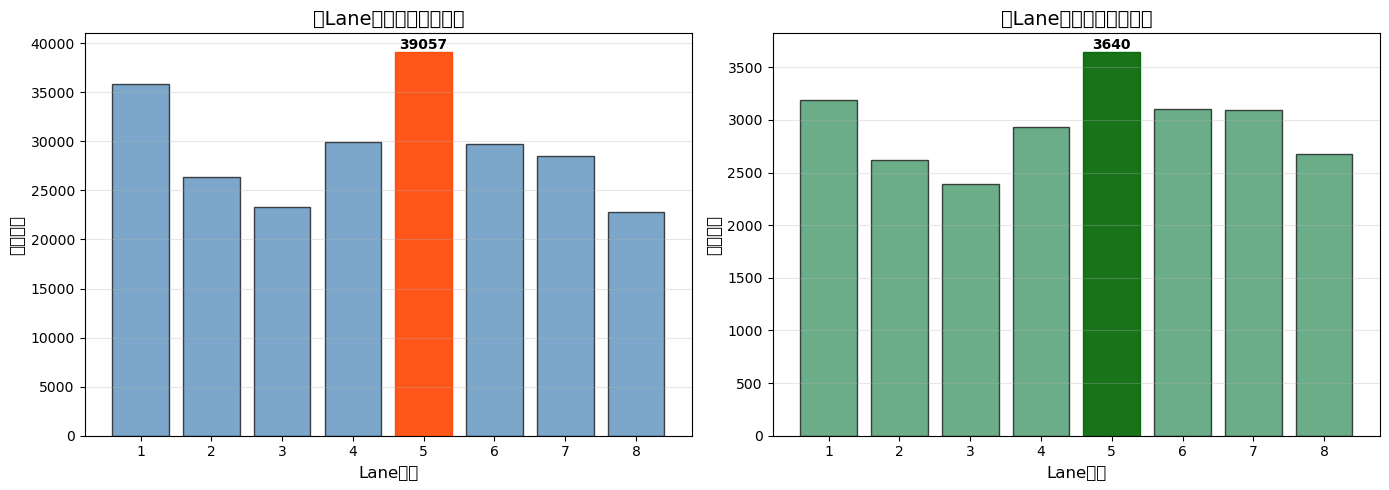


✓ 批量分析完成！


In [31]:
# 可视化比较所有lanes的信号强度
if 'results_list' in globals() and results_list:
    import matplotlib.pyplot as plt
    
    lanes = [r['lane'] for r in results_list]
    peaks = [r['peak'] for r in results_list]
    means = [r['mean'] for r in results_list]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 峰值比较
    bars1 = ax1.bar(lanes, peaks, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Lane编号', fontsize=12)
    ax1.set_ylabel('峰值强度', fontsize=12)
    ax1.set_title('各Lane峰值信号强度比较', fontsize=14)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 标注最大值
    max_idx = peaks.index(max(peaks))
    bars1[max_idx].set_color('orangered')
    bars1[max_idx].set_alpha(0.9)
    ax1.text(lanes[max_idx], peaks[max_idx], f'{peaks[max_idx]:.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 平均值比较
    bars2 = ax2.bar(lanes, means, color='seagreen', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Lane编号', fontsize=12)
    ax2.set_ylabel('平均强度', fontsize=12)
    ax2.set_title('各Lane平均信号强度比较', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 标注最大值
    max_idx = means.index(max(means))
    bars2[max_idx].set_color('darkgreen')
    bars2[max_idx].set_alpha(0.9)
    ax2.text(lanes[max_idx], means[max_idx], f'{means[max_idx]:.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ 批量分析完成！")
else:
    print("请先运行批量分析单元格！")

## 总结

本notebook实现了完整的交互式凝胶电泳图像分析功能：

### 主要功能
1. **InteractiveGelAnalyzer 类** - 核心分析工具
   - `analyze_panel()` - 自动检测方向，计算信号强度
   - `plot_results()` - 生成4子图可视化结果
   - `select_rectangle()` - 交互式鼠标框选

2. **背景校正算法** - 使用`scipy.ndimage.minimum_filter`估算并去除背景

3. **批量分析** - 可以批量处理多个lanes并比较

### 使用场景
- ✓ 单个lane/band的信号强度分析
- ✓ 垂直和水平方向自动检测
- ✓ 背景去除和信号校正
- ✓ 多个样品的批量定量比较
- ✓ 交互式实时分析

### 所有依赖包已安装在 `visualization` 环境中
- scipy (minimum_filter)
- matplotlib (RectangleSelector)
- numpy

## 🖱️ 交互式手动选择矩形

运行下面的单元格，然后：
1. 在图像上用鼠标**拖动**画出一个矩形
2. 松开鼠标后会自动显示分析结果
3. 可以多次选择不同的区域

**提示：** 如果在Jupyter中交互不方便，可以使用下面的手动指定坐标方式

🎯 交互式矩形选择已启动！

📌 使用说明：
1. 在下方图像上按住鼠标左键并拖动，画出一个矩形区域
2. 松开鼠标后，会自动分析并显示4个子图的结果
3. 可以重复选择多次，每次都会生成新的分析图

⚠️  注意：在某些Jupyter环境中，交互可能受限
   如果无法使用鼠标交互，请使用下面的手动指定坐标方式




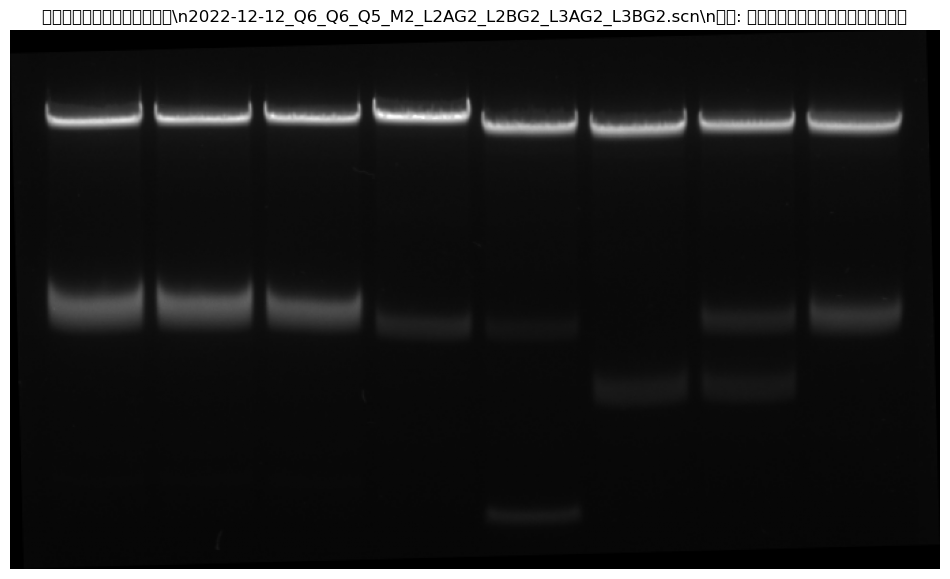


✓ 交互式选择器已创建
请在上方图像上拖动鼠标选择区域


In [32]:
# 启动交互式矩形选择器
if 'img_data' in globals() and img_data is not None:
    print("=" * 80)
    print("🎯 交互式矩形选择已启动！")
    print("=" * 80)
    print("\n📌 使用说明：")
    print("1. 在下方图像上按住鼠标左键并拖动，画出一个矩形区域")
    print("2. 松开鼠标后，会自动分析并显示4个子图的结果")
    print("3. 可以重复选择多次，每次都会生成新的分析图")
    print("\n⚠️  注意：在某些Jupyter环境中，交互可能受限")
    print("   如果无法使用鼠标交互，请使用下面的手动指定坐标方式\n")
    print("=" * 80 + "\n")
    
    # 创建分析器
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    
    # 启动交互式选择
    selector = analyzer.select_rectangle()
    
    print("\n✓ 交互式选择器已创建")
    print("请在上方图像上拖动鼠标选择区域")
else:
    print("❌ 请先运行上面的单元格加载图像数据！")

### 备用方案：手动指定矩形坐标

如果上面的交互式选择不能正常工作，可以使用这个方法手动指定坐标：

分析区域: 左上角(100, 50) → 右下角(140, 150)
区域大小: 40 × 100 像素

✓ 分析完成！
  方向: 垂直方向 (上→下)
  数据点数: 100
  原始信号峰值: 44913.9
  校正后信号峰值: 26323.8
  校正后信号平均值: 2616.5



/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_377624/2511770011.py:102: UserWarning: Glyph 21306 (\N{CJK UN

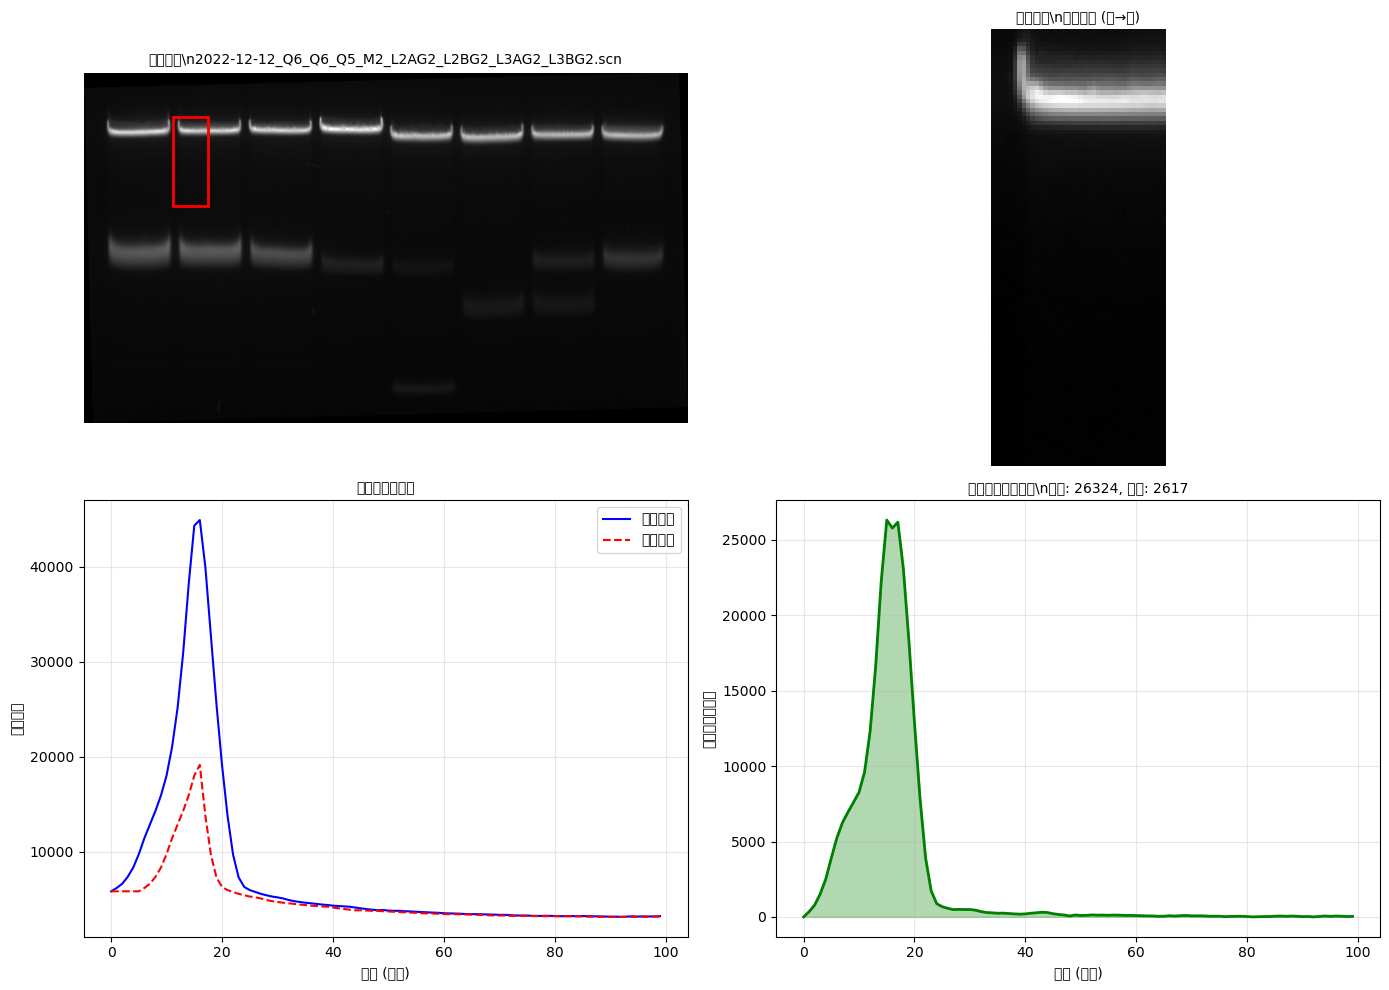

In [33]:
# 手动指定矩形坐标进行分析
# 修改下面的坐标值 (x1, y1, x2, y2) 来选择不同的区域

if 'img_data' in globals() and img_data is not None:
    # 👇 在这里修改坐标，指定你想分析的矩形区域
    x1, y1 = 100, 50   # 左上角坐标
    x2, y2 = 140, 150  # 右下角坐标
    # 👆 修改上面的数值来选择不同区域
    
    print(f"分析区域: 左上角({x1}, {y1}) → 右下角({x2}, {y2})")
    print(f"区域大小: {x2-x1} × {y2-y1} 像素\n")
    
    # 创建分析器并分析
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    analysis = analyzer.analyze_panel(x1, y1, x2, y2)
    
    # 显示分析信息
    print(f"✓ 分析完成！")
    print(f"  方向: {analysis['direction']}")
    print(f"  数据点数: {len(analysis['position'])}")
    print(f"  原始信号峰值: {analysis['profile'].max():.1f}")
    print(f"  校正后信号峰值: {analysis['corrected'].max():.1f}")
    print(f"  校正后信号平均值: {analysis['corrected'].mean():.1f}\n")
    
    # 绘制4子图结果
    fig = analyzer.plot_results(analysis)
    plt.show()
else:
    print("❌ 请先运行上面的单元格加载图像数据！")

### 🎚️ 使用滑动条交互式选择坐标

这个方法使用滑动条，更加直观和方便：

In [ ]:
# 使用ipywidgets滑动条交互式选择矩形
from ipywidgets import interactive, IntSlider, Button, Output, VBox, HBox
from IPython.display import display, clear_output

if 'img_data' in globals() and img_data is not None:
    height, width = img_data.shape
    
    # 创建输出区域
    output = Output()
    
    def analyze_region(x1, y1, x2, y2):
        """分析指定区域的回调函数"""
        with output:
            clear_output(wait=True)
            
            # 确保坐标有效
            if x2 <= x1 or y2 <= y1:
                print("❌ 错误：右下角坐标必须大于左上角坐标")
                return
            
            if x2 - x1 < 5 or y2 - y1 < 5:
                print("❌ 错误：矩形区域太小，请选择至少5×5像素的区域")
                return
            
            print(f"🔍 正在分析区域: ({x1}, {y1}) → ({x2}, {y2})")
            print(f"   区域大小: {x2-x1} × {y2-y1} 像素\n")
            
            # 创建分析器并分析
            analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
            analysis = analyzer.analyze_panel(x1, y1, x2, y2)
            
            # 显示分析信息
            print(f"✓ 分析完成！")
            print(f"  方向: {analysis['direction']}")
            print(f"  原始信号峰值: {analysis['profile'].max():.1f}")
            print(f"  校正后信号峰值: {analysis['corrected'].max():.1f}")
            print(f"  校正后信号平均值: {analysis['corrected'].mean():.1f}\n")
            
            # 绘制结果
            fig = analyzer.plot_results(analysis)
            plt.show()
    
    # 创建滑动条
    x1_slider = IntSlider(value=100, min=0, max=width-10, step=1, description='X1 (左):', continuous_update=False)
    y1_slider = IntSlider(value=50, min=0, max=height-10, step=1, description='Y1 (上):', continuous_update=False)
    x2_slider = IntSlider(value=140, min=10, max=width, step=1, description='X2 (右):', continuous_update=False)
    y2_slider = IntSlider(value=150, min=10, max=height, step=1, description='Y2 (下):', continuous_update=False)
    
    # 创建分析按钮
    analyze_button = Button(description='🔍 开始分析', button_style='primary', tooltip='点击分析选中区域')
    
    def on_analyze_click(b):
        analyze_region(x1_slider.value, y1_slider.value, x2_slider.value, y2_slider.value)
    
    analyze_button.on_click(on_analyze_click)
    
    # 显示界面
    print("=" * 80)
    print("🎚️ 交互式滑动条选择器")
    print("=" * 80)
    print(f"\n图像尺寸: {width} × {height} 像素")
    print("\n📌 使用说明：")
    print("1. 拖动下方的滑动条来调整矩形的位置和大小")
    print("2. X1, Y1 = 左上角坐标")
    print("3. X2, Y2 = 右下角坐标")
    print("4. 调整好后点击 '🔍 开始分析' 按钮\n")
    
    # 布局
    sliders = VBox([x1_slider, y1_slider, x2_slider, y2_slider])
    controls = VBox([sliders, analyze_button])
    
    display(controls)
    display(output)
    
else:
    print("❌ 请先运行上面的单元格加载图像数据！")

🎚️ 交互式滑动条选择器

图像尺寸: 683 × 396 像素

📌 使用说明：
1. 拖动下方的滑动条来调整矩形的位置和大小
2. X1, Y1 = 左上角坐标
3. X2, Y2 = 右下角坐标
4. 调整好后点击 '🔍 开始分析' 按钮



Output()

---

## 📊 三种交互式选择方式总结

本notebook提供了**三种**交互式选择矩形区域的方式：

### 方式1️⃣：鼠标拖动选择（RectangleSelector）
- ✅ 最直观：直接在图像上拖动鼠标画矩形
- ⚠️ 限制：某些Jupyter环境可能不支持
- 📍 位置：上方单元格

### 方式2️⃣：手动输入坐标
- ✅ 最精确：直接修改代码中的坐标值
- ✅ 适合批量分析：可以循环处理多个区域
- 📍 位置：备用方案单元格

### 方式3️⃣：滑动条交互（ipywidgets）
- ✅ 最方便：拖动滑动条实时调整
- ✅ 可视化好：有明确的坐标范围提示
- 📍 位置：刚才运行的单元格

**建议：** 优先尝试方式3的滑动条，如果不行再用方式2手动输入坐标。

---

## 🚀 快速开始指南

### 新手推荐流程：

1. **运行前3个单元格** → 导入库、定义类、加载图像
2. **使用滑动条方式**（向上翻找🎚️标题）：
   - 拖动4个滑动条调整矩形位置
   - 点击"🔍 开始分析"按钮
   - 查看生成的4子图分析结果
3. **想分析其他lane？** → 重新调整滑动条再点击按钮即可

### 高级用法：
- 批量分析多个lanes → 参考"示例3"单元格
- 比较不同样品 → 参考可视化柱状图单元格
- 导出数据 → 使用 `analysis['corrected']` 获取校正后的信号数组

### 测试：点击滑动条的"开始分析"按钮

如果上面的滑动条已显示，请：
1. 调整4个滑动条的值（或使用默认值）
2. 点击蓝色的"🔍 开始分析"按钮
3. 在下方查看分析结果

如果看不到滑动条，请向上滚动查找 "🎚️ 使用滑动条交互式选择坐标" 部分

In [35]:
# 查找并读取一个SCN文件作为测试
import glob
import os

scn_files = sorted(glob.glob("*.scn"))
print(f"找到 {len(scn_files)} 个SCN文件")

if scn_files:
    test_file = scn_files[0]
    print(f"\\n测试文件: {test_file}")
    
    # 读取图像数据
    img_data, img_info = read_scn_file_enhanced(test_file, prefer_mode='crop')
    print(f"图像尺寸: {img_data.shape}")
    print(f"图像信息: {img_info}")
else:
    print("未找到SCN文件！")

找到 1 个SCN文件
\n测试文件: 2022-12-12_Q6_Q6_Q5_M2_L2AG2_L2BG2_L3AG2_L3BG2.scn


ValueError: too many values to unpack (expected 2)

## 启动交互式分析

运行下面的单元格后：
1. 会显示凝胶图像
2. 用鼠标拖动选择一个矩形区域
3. 释放鼠标后自动显示分析结果（4个子图）

**使用说明：**
- 选择一个纵向或横向的lane区域
- 系统会自动检测长边方向
- 沿着长边计算平均信号强度
- 使用滚动最小值估算背景并去除

In [ ]:
# 创建分析器并启动交互式选择
if 'img_data' in globals():
    analyzer = InteractiveGelAnalyzer(img_data, os.path.basename(test_file))
    analyzer.select_rectangle()
else:
    print("请先运行上面的单元格加载图像数据！")